In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load and prepare data
df = pd.read_csv('../COS40007DataCleaning/combined_air_electricity_ipi_cleaned.csv')
print(f"Data shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())

Data shape: (60, 19)

First few rows:
         date  air_co  air_no2  air_o3  air_pm_10  air_pm_25  air_so2  \
0  2018-01-01   0.671   0.0078   0.015      19.14      11.43   0.0010   
1  2018-02-01   0.677   0.0069   0.024      26.06      16.75   0.0011   
2  2018-03-01   0.654   0.0074   0.019      24.84      15.61   0.0010   
3  2018-04-01   0.682   0.0075   0.019      25.64      16.34   0.0010   
4  2018-05-01   0.671   0.0076   0.017      22.60      14.54   0.0010   

   electricity_exports  electricity_local  electricity_local_commercial  \
0              109.820       11845.900250                   9390.080801   
1              101.500       11091.957006                   8561.415143   
2              103.785       12244.089947                   9659.320215   
3              102.002       12018.584577                   9340.784017   
4              142.261       12267.998390                   9525.937602   

   electricity_local_domestic  electricity_losses  electricity_total  \


In [3]:
# Prepare features and target
# Target: air_so2
# Features: ipi_growth_yoy_index_sa and electricity_local

X = df[['air_so2', 'electricity_local', 'electricity_local_commercial']].values
y = df['ipi_abs_index_sa'].values

print(f"Feature shape: {X.shape}")
print(f"Target shape: {y.shape}")

Feature shape: (60, 3)
Target shape: (60,)


In [4]:
# Train-test split (80/20)
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print(f"Training set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Training set size: 48 (80.0%)
Test set size: 12 (20.0%)

X_train shape: (48, 3)
y_train shape: (48,)
X_test shape: (12, 3)
y_test shape: (12,)


In [5]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit on Train, transform both
train_X_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))

test_X_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

In [6]:
def create_sliding_windows(X_data, y_data, timesteps):
    X_windows, y_targets = [], []
    for i in range(len(X_data) - timesteps):
        X_windows.append(X_data[i : i + timesteps])  # Past 'timesteps' months
        y_targets.append(y_data[i + timesteps])       # Next month's target
    return np.array(X_windows), np.array(y_targets)


window_size = 4
X_train_final, y_train_final = create_sliding_windows(train_X_scaled, y_train_scaled, window_size)
X_test_final, y_test_final = create_sliding_windows(test_X_scaled, y_test_scaled, window_size)

print("LSTM Input Shape:", X_train_final.shape)


LSTM Input Shape: (44, 4, 3)


In [7]:
model = Sequential([
    LSTM(
        16,
        input_shape=(
            window_size,
            X_train_final.shape[2]
        )
    ),

    Dense(
        8,
        activation='relu'
    ),

    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

print("Model Architecture:")
print(model.summary())

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,425 (5.57 KB)

 Trainable params: 1,425 (5.57 KB)

 Non-trainable params: 0 (0.00 B)

None


In [8]:
from tensorflow.keras.callbacks import EarlyStopping

print("Training the LSTM model...")

# Define the Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',     # Watch the validation split's loss
    patience=30,            # Number of epochs to wait for an improvement before stopping
    restore_best_weights=True # Automatically rolls back model weights to the best epoch
)

history = model.fit(
    X_train_final, y_train_final,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed!")

Training the LSTM model...
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - loss: 0.8967 - val_loss: 0.9009
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.7654 - val_loss: 0.7783
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.6494 - val_loss: 0.6677
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5452 - val_loss: 0.5687
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.4537 - val_loss: 0.5001
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3772 - val_loss: 0.4597
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.3226 - val_loss: 0.4251
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.2886 - val_loss: 0.3917
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.2604 - val_loss: 0.3596
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.2355 - val_loss: 0.3284
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.2102 - val_loss: 0.2988
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/

In [9]:
# Make predictions
print("Making predictions...")
y_train_pred_scaled = model.predict(X_train_final)
y_test_pred_scaled = model.predict(X_test_final)

# Inverse transform predictions and actual values to original scale
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)
y_train_actual = scaler_y.inverse_transform(y_train_final.reshape(-1, 1))

y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_final.reshape(-1, 1))

print("Predictions completed!")

Making predictions...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predictions completed!


In [10]:
# Evaluate model performance
# Training metrics
train_rmse = np.sqrt(mean_squared_error(y_train_actual, y_train_pred))
train_mae = mean_absolute_error(y_train_actual, y_train_pred)
train_r2 = r2_score(y_train_actual, y_train_pred)

# Testing metrics
test_rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
test_mae = mean_absolute_error(y_test_actual, y_test_pred)
test_r2 = r2_score(y_test_actual, y_test_pred)

print("="*50)
print("EVALUATION METRICS")
print("="*50)
print("\nTRAINING SET METRICS:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print(f"  R²:   {train_r2:.4f}")

print("\nTEST SET METRICS:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE:  {test_mae:.4f}")
print(f"  R²:   {test_r2:.4f}")
print("="*50)

EVALUATION METRICS

TRAINING SET METRICS:
  RMSE: 6.7843
  MAE:  4.0796
  R²:   0.0120

TEST SET METRICS:
  RMSE: 7.3748
  MAE:  7.0478
  R²:   -11.4242


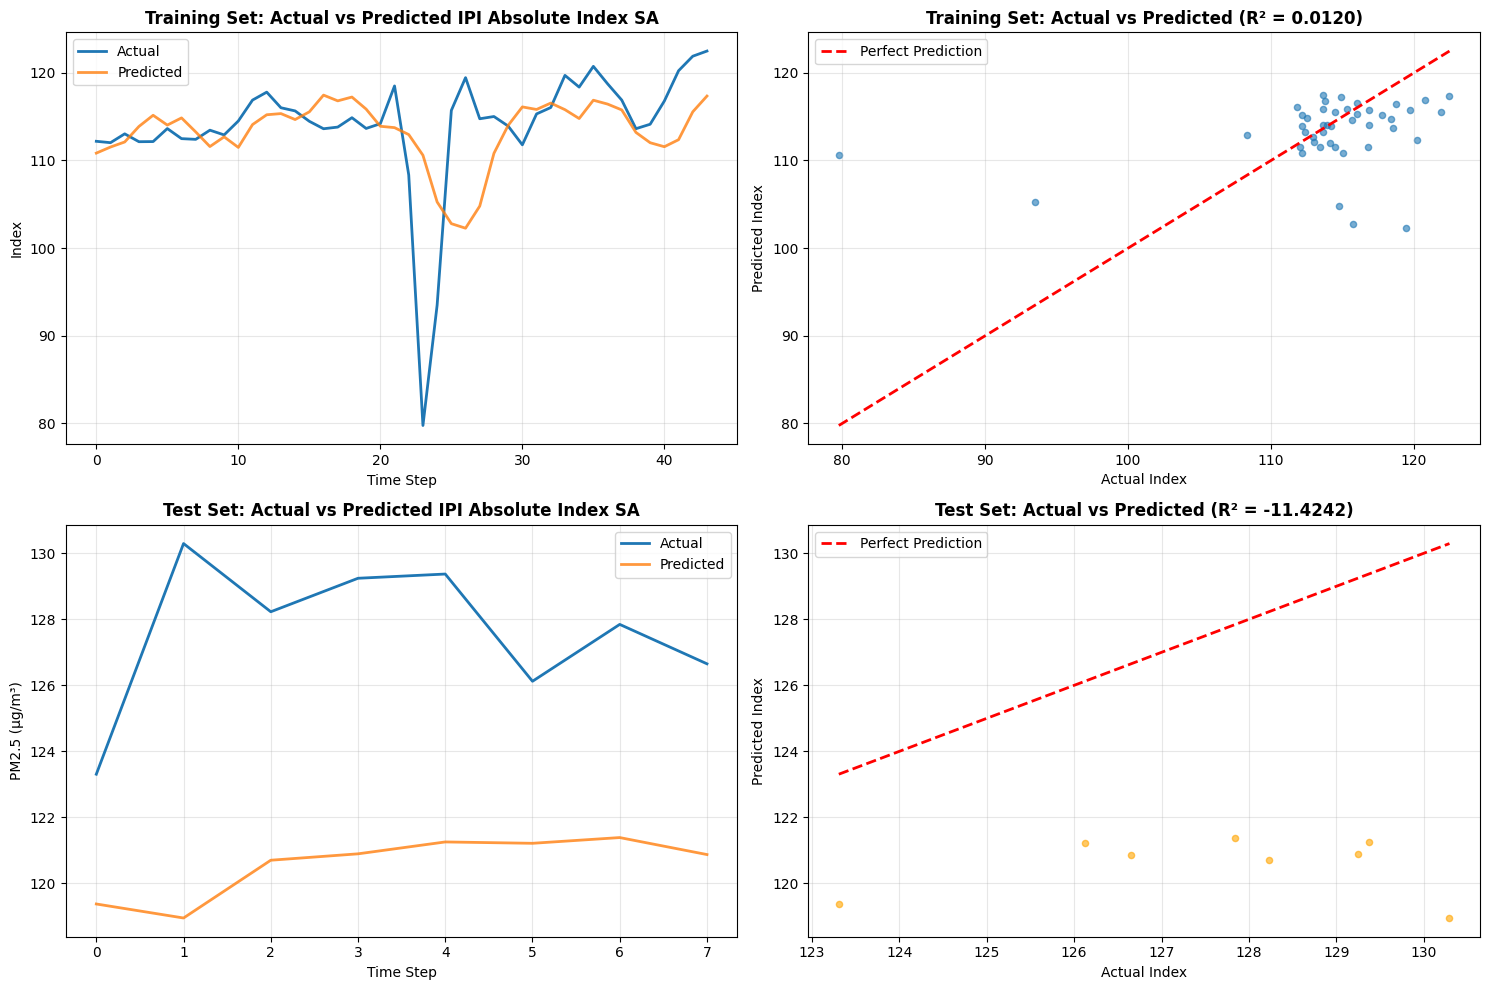

Plots saved as 'lstm_predictions.png'


In [11]:
# Plot actual vs predicted for both train and test sets
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Training set - Time series plot
axes[0, 0].plot(y_train_actual, label='Actual', linewidth=2)
axes[0, 0].plot(y_train_pred, label='Predicted', linewidth=2, alpha=0.8)
axes[0, 0].set_title('Training Set: Actual vs Predicted IPI Absolute Index SA', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Time Step')
axes[0, 0].set_ylabel('Index')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Training set - Scatter plot
axes[0, 1].scatter(y_train_actual, y_train_pred, alpha=0.6, s=20)
axes[0, 1].plot([y_train_actual.min(), y_train_actual.max()], 
                 [y_train_actual.min(), y_train_actual.max()], 
                 'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_title(f'Training Set: Actual vs Predicted (R² = {train_r2:.4f})', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Actual Index')
axes[0, 1].set_ylabel('Predicted Index')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Test set - Time series plot
axes[1, 0].plot(y_test_actual, label='Actual', linewidth=2)
axes[1, 0].plot(y_test_pred, label='Predicted', linewidth=2, alpha=0.8)
axes[1, 0].set_title('Test Set: Actual vs Predicted IPI Absolute Index SA', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Time Step')
axes[1, 0].set_ylabel('PM2.5 (µg/m³)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Test set - Scatter plot
axes[1, 1].scatter(y_test_actual, y_test_pred, alpha=0.6, s=20, color='orange')
axes[1, 1].plot([y_test_actual.min(), y_test_actual.max()], 
                 [y_test_actual.min(), y_test_actual.max()], 
                 'r--', lw=2, label='Perfect Prediction')
axes[1, 1].set_title(f'Test Set: Actual vs Predicted (R² = {test_r2:.4f})', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Actual Index')
axes[1, 1].set_ylabel('Predicted Index')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plots saved as 'lstm_predictions.png'")

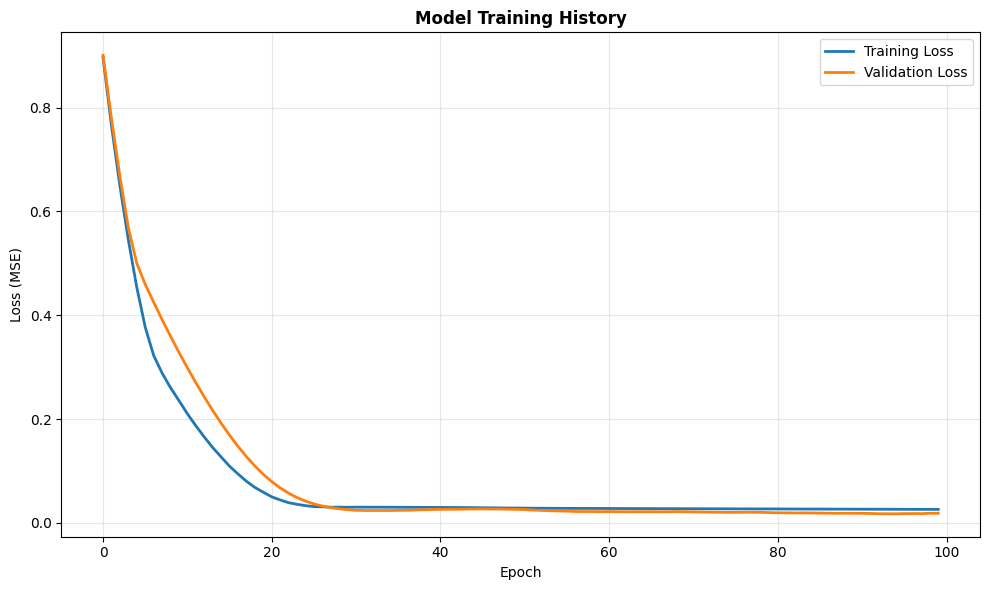

Training history plot saved as 'training_history.png'


In [12]:
# Plot training history
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax.set_title('Model Training History', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training history plot saved as 'training_history.png'")